In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import marimo as mo
import numpy as np
import tensorflow as tf

2026-03-18 10:48:54.242842: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def record_parse_function(proto, feature_description):
    record = tf.io.parse_single_example(proto, feature_description)

    # Measured carrier frequency offset between MOBTX and each receive antenna.
    cfo = tf.ensure_shape(tf.io.parse_tensor(record["cfo"], out_type = tf.float32), (32))

    # Channel coefficients for all antennas, over all subcarriers, real and imaginary parts
    csi = tf.ensure_shape(tf.io.parse_tensor(record["csi"], out_type = tf.float32), (32, 1024, 2))

    # Time in seconds to closest known tachymeter position. Indicates quality of linear interpolation.
    gt_interp_age_tachy = tf.ensure_shape(record["gt-interp-age-tachy"], ())

    # Position of transmitter determined by a tachymeter pointed at a prism mounted on top of the antenna, in meters (X / Y / Z coordinates)
    pos_tachy = tf.ensure_shape(tf.io.parse_tensor(record["pos-tachy"], out_type = tf.float64), (3))

    # Signal-to-Noise ratio estimates for all antennas
    snr = tf.ensure_shape(tf.io.parse_tensor(record["snr"], out_type = tf.float32), (32))

    # Timestamp since start of measurement campaign, in seconds
    time = tf.ensure_shape(record["time"], ())

    return cfo, csi, gt_interp_age_tachy, pos_tachy, snr, time

In [4]:
p = Path('data/dichasus')
files = [f for f in p.glob("*tfrecords")]
print(files)

[PosixPath('data/dichasus/dichasus-cf02.tfrecords'), PosixPath('data/dichasus/dichasus-cf03.tfrecords'), PosixPath('data/dichasus/dichasus-cf04.tfrecords')]


In [5]:
raw_dataset = tf.data.TFRecordDataset(files)

feature_description = {
    "cfo": tf.io.FixedLenFeature([], tf.string, default_value = ''),
    "csi": tf.io.FixedLenFeature([], tf.string, default_value = ''),
    "gt-interp-age-tachy": tf.io.FixedLenFeature([], tf.float32, default_value = 0),
    "pos-tachy": tf.io.FixedLenFeature([], tf.string, default_value = ''),
    "snr": tf.io.FixedLenFeature([], tf.string, default_value = ''),
    "time": tf.io.FixedLenFeature([], tf.float32, default_value = 0),
}

func = lambda x: record_parse_function(x, feature_description)
dataset = raw_dataset.map(func, num_parallel_calls = tf.data.experimental.AUTOTUNE)

I0000 00:00:1773827456.745838 3523324 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10687 MB memory:  -> device: 0, name: NVIDIA TITAN V, pci bus id: 0000:04:00.0, compute capability: 7.0


In [ ]:
groundtruth_positions = []
csi_time_domain = []
timestamps = []

for _, csi, _, pos, _, time in dataset.batch(1000):
    csi_time_domain.append(csi.numpy())
    groundtruth_positions.append(pos.numpy())
    timestamps.append(time.numpy())

csi_time_domain = np.concatenate(csi_time_domain)
groundtruth_positions = np.concatenate(groundtruth_positions)
timestamps = np.concatenate(timestamps)

2026-03-18 10:51:19.004936: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-03-18 10:52:38.327471: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


SyntaxError: 'return' outside function (3220829082.py, line 13)

In [7]:
np.savez('data/csi', csi_time_domain)
np.savez('data/positions', groundtruth_positions)
np.savez('data/timestamps', timestamps)

In [8]:
def plot_colorized(positions, groundtruth_positions, title = None, show = True, alpha = 1.0):
    # Generate RGB colors for datapoints
    center_point = np.zeros(2, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    def NormalizeData(in_data):
        return (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions[:,0:2] - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 1])

    # Plot datapoints
    plt.figure(figsize=(6, 6))
    if title is not None:
        plt.title(title, fontsize=16)
    plt.scatter(positions[:, 0], positions[:, 1], c = rgb_values, alpha = alpha, s = 10, linewidths = 0)
    plt.xlabel("x coordinate")
    plt.ylabel("y coordinate")
    if show:
        plt.show()

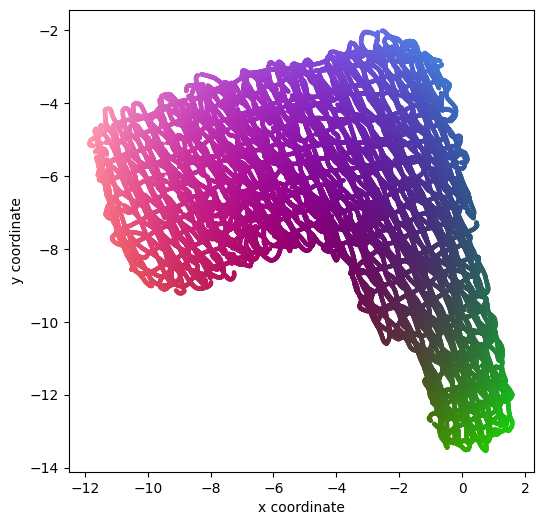

In [9]:
plot_colorized(groundtruth_positions, groundtruth_positions)